<a href="https://colab.research.google.com/github/tk1981215/Machine-Learning/blob/main/ML_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [15]:
df = pd.read_csv("Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [16]:
print(df.isnull())

        Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0    False          False         False          False         False    False
1    False          False         False          False         False    False
2    False          False         False          False         False    False
3    False          False         False          False         False    False
4    False          False         False          False         False    False
..     ...            ...           ...            ...           ...      ...
145  False          False         False          False         False    False
146  False          False         False          False         False    False
147  False          False         False          False         False    False
148  False          False         False          False         False    False
149  False          False         False          False         False    False

[150 rows x 6 columns]


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [19]:
X = df.drop("Species" , axis=1)
y = df["Species"]

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print("Trainng samples : " , len(X_train))
print("Testing samples : " , len(X_test))

Trainng samples :  105
Testing samples :  45


In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
print("X_train Scaled data" , X_train_scaled[:5])
print("X_test Scaled data" , X_test_scaled[:5])

X_train Scaled data [[ 0.53726272 -0.90045861 -1.21813584 -0.44283471 -0.13515309]
 [-0.15718848  0.38036614 -1.8819988   0.40257701  0.38088597]
 [-1.29145876 -0.90045861  1.65860364 -1.28824644 -1.1672312 ]
 [ 1.57893951  1.07899781  0.33087773  1.19162795  1.41296408]
 [ 0.56041109 -0.20182693 -0.55427288  0.17713389  0.12286644]]
X_test Scaled data [[ 0.76223626  2.07292879 -0.42469145  1.51460381  0.84857614]
 [-0.24863299  0.44355245 -0.42469145  0.58413048  0.29715482]
 [ 1.35956809  0.71511517 -0.68648754  0.81674881  0.43501015]
 [-0.4094531   0.71511517  0.62249294  0.58413048  0.57286548]
 [ 1.22172228  0.44355245 -0.16289535  0.70043965  0.84857614]]


In [34]:
model = SVC(kernel="rbf" , C = 1.0 , gamma = 0.1)
model.fit(X_train_scaled , y_train)
print("Model trained successfully...!")

Model trained successfully...!


In [35]:
y_pred = model.predict(X_test_scaled)
print("Predicted values : " , y_pred)

Predicted values :  ['Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor']


In [39]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : " , accuracy)

Accuracy :  0.9777777777777777


In [41]:
print("Classification report : ")
print(classification_report(y_test,y_pred))

Classification report : 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.93      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



In [42]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)


Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


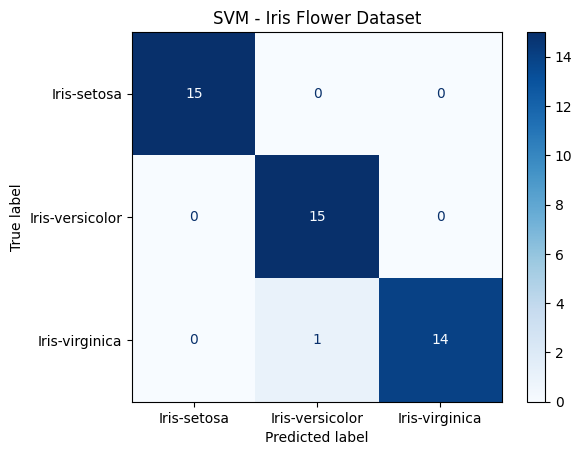

In [45]:
disp.plot(cmap="Blues")
plt.title("SVM - Iris Flower Dataset")
plt.show()

In [50]:
new_flower = [[0, 5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("\nNew flower prediction:",prediction[0])



New flower prediction: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
